lumapi imported from: C:\Program Files\Lumerical\v202\api\python\lumapi.py
design region: 6.00 x 3.50 um, grid (301, 176), n_core=1.7000, n_clad=1.4537
Configured global source band: 660-850 nm
Running FDTD ...

================  TRANSMITTANCE SUMMARY  ================
  band measured           : 660-850 nm
  input  T_in  @ 780 nm : 0.9967  (sanity, ~1)
  output T_out total      : 0.9889
  output T_fund (TE0)     : 0.9619
  insertion loss @ 780 nm: 0.169 dB
  band-averaged IL (TE0)  : 0.230 dB


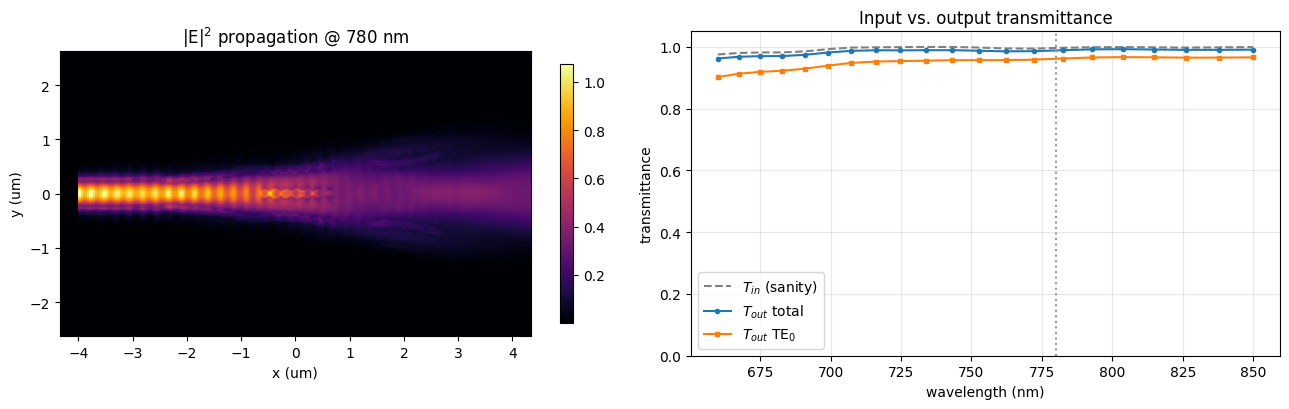

Saved: taper_fdtd_results.png and taper_fdtd_propagation.fsp


In [3]:
# ============================================================================
#  Taper inverse-design — FDTD propagation & transmittance validation  (v3)
#  Single-cell Jupyter script. Loads the optimized density, rebuilds it as a
#  2D FDTD problem (same effective-index model as the lumopt optimization),
#  propagates TE0 through it and measures input vs. output transmittance.
#
#  Requires: Ansys Lumerical (provides lumapi) + numpy + matplotlib.
#  lumapi import follows the OS-aware logic of the sin_mode_analysis repo.
# ============================================================================
import os, sys, platform
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------------------------------------------------
# 0) CONFIG  (edit these)
# ----------------------------------------------------------------------------
LUMERICAL_VERSION = "v202"   # folder under C:\Program Files\Lumerical\  (or /opt/lumerical/)
NPZ_PATH = "LUM_SiN_taper_invdes_780nm_220nm_V1_final_params.npz"  # optimized density
HIDE_CAD = False             # set True to run the FDTD CAD hidden (headless)

# operating band (must match the optimization)
LAMBDA0_NM = 780.0
WL_MIN_NM, WL_MAX_NM = 660.0, 850.0
NFREQ = 21                   # frequency points recorded across the band

# taper endpoints (the fixed waveguides on either side of the design region)
W_SM_NM = 500.0              # input single-mode routing width  [nm]
W_MM_NM = 2500.0             # output multimode access width     [nm]
H_CORE_NM = 220.0            # core height (bookkeeping; 2D ignores z)

# discretization
DENSITY_THRESHOLD = 0.5      # density -> two-level (SiN core where rho > threshold)
MESH_DX_NM = 20.0            # mesh override over the design region [nm]
MESH_ACCURACY = 2            # FDTD mesh accuracy (1-8); 2 is a fast validation

FSP_PATH = "taper_fdtd_propagation.fsp"

# ----------------------------------------------------------------------------
# 1) lumapi import  (OS-aware, same logic as sin_mode_analysis)
# ----------------------------------------------------------------------------
def import_lumapi(version=LUMERICAL_VERSION):
    if platform.system() == "Windows":
        root = rf"C:\Program Files\Lumerical\{version}"
        api  = rf"{root}\api\python"
        binp = rf"{root}\bin"
    else:
        root = f"/opt/lumerical/{version}"
        api  = f"{root}/api/python"
        binp = f"{root}/bin"
    if "lumapi" in sys.modules:
        del sys.modules["lumapi"]
    if api not in sys.path:
        sys.path.insert(0, api)
    if platform.system() == "Windows":
        if hasattr(os, "add_dll_directory"):
            os.add_dll_directory(binp)
        else:
            os.environ["PATH"] = binp + ";" + os.environ.get("PATH", "")
    assert os.path.isdir(api), f"Lumerical API path not found:\n  {api}\nCheck LUMERICAL_VERSION."
    import lumapi
    print("lumapi imported from:", lumapi.__file__)
    return lumapi

# Optional NumPy-2.0 safety shim (harmless; mirrors the optimization package).
def _patch_numpy():
    repl = {"trapz": "trapezoid", "in1d": "isin", "row_stack": "vstack",
            "product": "prod", "alltrue": "all", "sometrue": "any"}
    for old, new in repl.items():
        if not hasattr(np, old) and hasattr(np, new):
            setattr(np, old, getattr(np, new))
    for s, v in {"NaN": np.nan, "Inf": np.inf}.items():
        if not hasattr(np, s):
            setattr(np, s, v)
_patch_numpy()

lumapi = import_lumapi()

# ----------------------------------------------------------------------------
# 2) Load the optimized density and convert it to a two-level index map
# ----------------------------------------------------------------------------
d = np.load(NPZ_PATH)
rho = np.asarray(d["params"])              # (nx, ny) density in [0,1]
x   = np.asarray(d["x"]).ravel()           # [m], propagation axis, centered at 0
y   = np.asarray(d["y"]).ravel()           # [m], transverse axis,  centered at 0
n_core = float(np.sqrt(d["eps_max"]))      # TE0 slab effective index (~1.70)
n_clad = float(np.sqrt(d["eps_min"]))      # SiO2 (~1.454)

opt_size_x = float(x.max() - x.min())      # design-region length [m]
opt_size_y = float(y.max() - y.min())      # design-region width  [m]
print(f"design region: {opt_size_x*1e6:.2f} x {opt_size_y*1e6:.2f} um, "
      f"grid {rho.shape}, n_core={n_core:.4f}, n_clad={n_clad:.4f}")

# two-level index pattern (SiN where rho>threshold, else SiO2); extruded over z
n2d = np.where(rho > DENSITY_THRESHOLD, n_core, n_clad)     # (nx, ny)
z = np.array([-0.5e-6, 0.5e-6])
n3d = np.repeat(n2d[:, :, None], 2, axis=2)                 # (nx, ny, 2)

# ----------------------------------------------------------------------------
# 3) Geometry / monitor coordinates (SI metres)
# ----------------------------------------------------------------------------
W_SM, W_MM, H = W_SM_NM*1e-9, W_MM_NM*1e-9, H_CORE_NM*1e-9
LAMBDA0, WL_MIN, WL_MAX = LAMBDA0_NM*1e-9, WL_MIN_NM*1e-9, WL_MAX_NM*1e-9
mx, my = 1.4e-6, 0.9e-6                     # x / y margins around the design region
size_x = opt_size_x + 2*mx
size_y = opt_size_y + 2*my
x_in_edge  = -opt_size_x/2                  # design region starts here (left)
x_out_edge =  opt_size_x/2                  # design region ends here  (right)
x_src   = -size_x/2 + 0.4e-6
x_Tin   = -size_x/2 + 0.8e-6
x_Tout  =  size_x/2 - 0.6e-6
y_in_span  = W_SM + 1.2e-6
y_out_span = W_MM + 1.0e-6

# ----------------------------------------------------------------------------
# 4) Build the FDTD simulation
# ----------------------------------------------------------------------------
fdtd = lumapi.FDTD(hide=HIDE_CAD)
try:
    fdtd.switchtolayout(); fdtd.deleteall()

    # input single-mode waveguide
    fdtd.addrect(); fdtd.set("name", "input_wg")
    fdtd.set("x min", -size_x/2); fdtd.set("x max", x_in_edge)
    fdtd.set("y", 0.0); fdtd.set("y span", W_SM)
    fdtd.set("z", 0.0); fdtd.set("z span", H); fdtd.set("index", n_core)

    # output multimode waveguide
    fdtd.addrect(); fdtd.set("name", "output_wg")
    fdtd.set("x min", x_out_edge); fdtd.set("x max", size_x/2)
    fdtd.set("y", 0.0); fdtd.set("y span", W_MM)
    fdtd.set("z", 0.0); fdtd.set("z span", H); fdtd.set("index", n_core)

    # the optimized taper, imported as a spatial (n,k) index pattern
    fdtd.addimport(); fdtd.set("name", "taper")
    fdtd.importnk2(n3d.astype(complex), x, y, z)

    # 2D FDTD region (effective-index model: background = SiO2)
    fdtd.addfdtd()
    fdtd.set("dimension", "2D")
    fdtd.set("background index", n_clad)
    fdtd.set("mesh accuracy", MESH_ACCURACY)
    fdtd.set("x min", -size_x/2); fdtd.set("x max", size_x/2)
    fdtd.set("y min", -size_y/2); fdtd.set("y max", size_y/2)
    fdtd.set("auto shutoff min", 1e-6)

    # mesh override over the design region (match the optimization pitch)
    fdtd.addmesh(); fdtd.set("name", "opt_mesh")
    fdtd.set("x", 0.0); fdtd.set("x span", opt_size_x)
    fdtd.set("y", 0.0); fdtd.set("y span", opt_size_y)
    fdtd.set("override x mesh", True); fdtd.set("dx", MESH_DX_NM*1e-9)
    fdtd.set("override y mesh", True); fdtd.set("dy", MESH_DX_NM*1e-9)
    fdtd.set("override z mesh", False)

    # fundamental-TE mode source at the input
    fdtd.addmode(); fdtd.set("name", "source")
    fdtd.set("injection axis", "x-axis"); fdtd.set("direction", "Forward")
    fdtd.set("x", x_src); fdtd.set("y", 0.0); fdtd.set("y span", y_in_span)
    fdtd.set("z", 0.0); fdtd.set("z span", 1e-6)
    fdtd.set("mode selection", "fundamental TE mode")

    # input transmittance monitor (just after the source)
    fdtd.addpower(); fdtd.set("name", "T_in")
    fdtd.set("monitor type", "2D X-normal")
    fdtd.set("x", x_Tin); fdtd.set("y", 0.0); fdtd.set("y span", y_in_span)

    # output transmittance monitor (total power)
    fdtd.addpower(); fdtd.set("name", "T_out")
    fdtd.set("monitor type", "2D X-normal")
    fdtd.set("x", x_Tout); fdtd.set("y", 0.0); fdtd.set("y span", y_out_span)

    # mode-expansion monitor at the output -> fundamental-TE transmittance
    fdtd.addmodeexpansion(); fdtd.set("name", "exp_out")
    fdtd.set("monitor type", "2D X-normal")
    fdtd.set("x", x_Tout); fdtd.set("y", 0.0); fdtd.set("y span", y_out_span)
    fdtd.set("mode selection", "fundamental TE mode")
    fdtd.setexpansion("out", "T_out")        # link expansion to the T_out DFT monitor

    # field-profile monitor for the propagation image
    fdtd.addpower(); fdtd.set("name", "field_xy")
    fdtd.set("monitor type", "2D Z-normal")
    fdtd.set("x", 0.0); fdtd.set("x span", size_x*0.98)
    fdtd.set("y", 0.0); fdtd.set("y span", size_y*0.98)

    # broadband settings across the band  (force it so it cannot fall back to
    # the default 400-700 nm range)
    fdtd.setglobalsource("set wavelength", True)
    fdtd.setglobalsource("wavelength start", WL_MIN)
    fdtd.setglobalsource("wavelength stop",  WL_MAX)
    fdtd.setglobalmonitor("use source limits", True)
    fdtd.setglobalmonitor("frequency points", NFREQ)

    # belt-and-suspenders: also pin the band on the mode source itself
    try:
        fdtd.setnamed("source", "override global source settings", True)
        fdtd.setnamed("source", "set wavelength", True)
        fdtd.setnamed("source", "wavelength start", WL_MIN)
        fdtd.setnamed("source", "wavelength stop",  WL_MAX)
    except Exception as e:
        print("note: per-source band override skipped:", e)

    # verify BEFORE running
    ws = fdtd.getglobalsource("wavelength start")
    we = fdtd.getglobalsource("wavelength stop")
    print(f"Configured global source band: {ws*1e9:.0f}-{we*1e9:.0f} nm")
    assert abs(ws-WL_MIN) < 1e-9 and abs(we-WL_MAX) < 1e-9, \
        "Band still not set to 660-850 nm - check the global source mode."

    fdtd.save(FSP_PATH)
    print("Running FDTD ...")
    fdtd.run()
    fdtd.save(FSP_PATH)   # persist results in the .fsp

    # ------------------------------------------------------------------------
    # 5) Extract transmittances
    #    'lambda' is a coordinate inside the "T" dataset, not a standalone
    #    result, so we read the dataset and pull lambda + T from it.
    # ------------------------------------------------------------------------
    C0 = 299792458.0
    def monitor_T(name):
        """Return (lambda[m], |T|) for a power monitor, robust across versions."""
        try:
            R = fdtd.getresult(name, "T")                      # dataset {lambda, f, T}
            lam = np.squeeze(np.asarray(R["lambda"])).ravel()
            T   = np.squeeze(np.asarray(R["T"])).ravel()
            return lam, np.abs(T)
        except Exception:
            T = np.squeeze(np.asarray(fdtd.transmission(name))).ravel()
            f = np.squeeze(np.asarray(fdtd.getdata(name, "f"))).ravel()
            return C0 / f, np.abs(T)

    lam,  T_out = monitor_T("T_out")
    _,    T_in  = monitor_T("T_in")

    # fundamental-TE transmittance from the mode-expansion monitor
    try:
        exp = fdtd.getresult("exp_out", "expansion for out")
        key = "T_forward" if "T_forward" in exp else ("T_net" if "T_net" in exp else None)
        T_fund = np.abs(np.squeeze(np.asarray(exp[key]))).ravel()
    except Exception as e:
        print("WARN: mode-expansion result unavailable, using total T_out.", e)
        T_fund = T_out.copy()

    # order by wavelength ascending (guard against any length mismatch)
    order = np.argsort(lam)
    def _reorder(a):
        a = np.asarray(a).ravel()
        return a[order] if a.size == order.size else a
    lam    = lam[order]
    T_in   = _reorder(T_in)
    T_out  = _reorder(T_out)
    T_fund = _reorder(T_fund)
    if T_fund.size != lam.size:
        T_fund = T_out.copy()
    if T_in.size != lam.size:
        T_in = np.full(lam.size, np.nan)
    lam_nm = lam*1e9

    i0 = int(np.argmin(np.abs(lam - LAMBDA0)))
    IL0   = -10*np.log10(max(T_fund[i0], 1e-12))
    IL_av = -10*np.log10(max(float(np.mean(T_fund)), 1e-12))

    print("\n================  TRANSMITTANCE SUMMARY  ================")
    print(f"  band measured           : {lam_nm.min():.0f}-{lam_nm.max():.0f} nm")
    print(f"  input  T_in  @ {LAMBDA0_NM:.0f} nm : {T_in[i0]:.4f}  (sanity, ~1)")
    print(f"  output T_out total      : {T_out[i0]:.4f}")
    print(f"  output T_fund (TE0)     : {T_fund[i0]:.4f}")
    print(f"  insertion loss @ {LAMBDA0_NM:.0f} nm: {IL0:.3f} dB")
    print(f"  band-averaged IL (TE0)  : {IL_av:.3f} dB")
    print("========================================================")

    # ------------------------------------------------------------------------
    # 6) Field profile at lambda0
    # ------------------------------------------------------------------------
    F  = fdtd.getresult("field_xy", "E")
    E  = np.asarray(F["E"]); xf = np.asarray(F["x"]).ravel(); yf = np.asarray(F["y"]).ravel()
    lamf = np.asarray(F["lambda"]).ravel()
    fi = int(np.argmin(np.abs(lamf - LAMBDA0)))
    E = np.squeeze(E)                      # drop singleton z -> (nx, ny, nf, 3) (or (nx, ny, 3))
    if E.ndim == 4:
        Ec = E[:, :, fi, :]
    elif E.ndim == 3:
        Ec = E
    else:
        Ec = E.reshape(xf.size, yf.size, -1)[:, :, :3]
    I  = np.sum(np.abs(Ec)**2, axis=-1)             # (nx, ny)

    # ------------------------------------------------------------------------
    # 7) Plots
    # ------------------------------------------------------------------------
    fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
    pc = ax[0].pcolormesh(xf*1e6, yf*1e6, I.T, shading="auto", cmap="inferno")
    ax[0].set_xlabel("x (um)"); ax[0].set_ylabel("y (um)")
    ax[0].set_title(f"|E|$^2$ propagation @ {LAMBDA0_NM:.0f} nm"); ax[0].set_aspect("equal")
    fig.colorbar(pc, ax=ax[0], shrink=0.8)

    ax[1].plot(lam_nm, T_in,   "--", color="0.5", label="$T_{in}$ (sanity)")
    ax[1].plot(lam_nm, T_out,  "-o", ms=3, label="$T_{out}$ total")
    ax[1].plot(lam_nm, T_fund, "-s", ms=3, label="$T_{out}$ TE$_0$")
    ax[1].axvline(LAMBDA0_NM, ls=":", color="0.6")
    ax[1].set_xlabel("wavelength (nm)"); ax[1].set_ylabel("transmittance")
    ax[1].set_ylim(0, 1.05); ax[1].grid(alpha=0.3); ax[1].legend()
    ax[1].set_title("Input vs. output transmittance")
    fig.tight_layout()
    fig.savefig("taper_fdtd_results.png", dpi=200)
    plt.show()
    print("Saved: taper_fdtd_results.png and", FSP_PATH)

finally:
    fdtd.close()